In [13]:
# INTEGRANTES: (Pon aquí vuestros nombres)
# ACTIVIDAD 5: Comparativa de Modelos Ensemble

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Importar modelos y métricas
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Configuración de gráficas
sns.set_style("whitegrid")
import warnings
warnings.filterwarnings('ignore') # Para limpiar advertencias molestas

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [14]:
# 1. Carga del dataset
df = sns.load_dataset("titanic")

print("--- 1.1 VISTA PREVIA ---")
display(df.head())

print("\n--- 1.2 INFORMACIÓN DEL DATASET ---")
print(df.info())

print("\n--- 1.3 VALORES NULOS ---")
print(df.isnull().sum())

print("\n--- 1.4 BALANCE DE CLASES (TARGET: SURVIVED) ---")
print(df['survived'].value_counts(normalize=True))
# 0 = No sobrevivió, 1 = Sobrevivió

--- 1.1 VISTA PREVIA ---


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



--- 1.2 INFORMACIÓN DEL DATASET ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

--- 1.3 VALORES NULOS ---
survived  

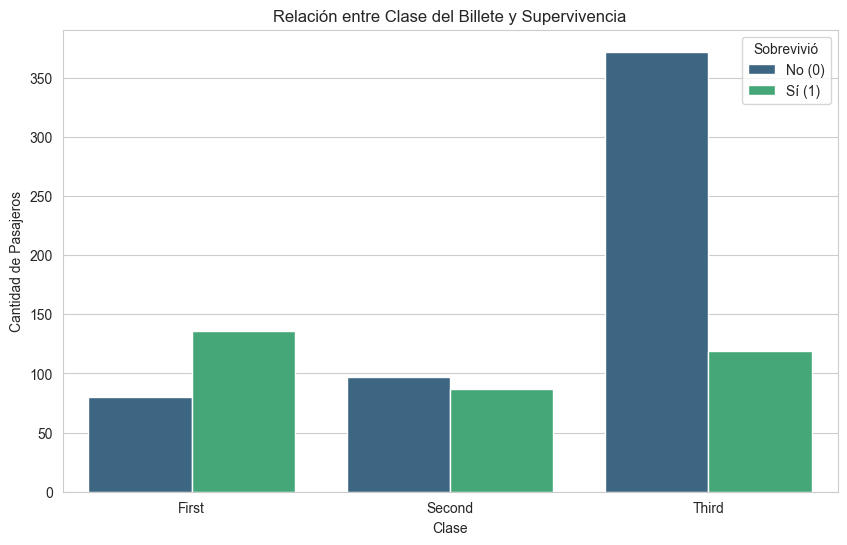

Descripción: Se observa que la 1ª clase tuvo mayor tasa de supervivencia, mientras que la 3ª clase tuvo la mayor mortalidad.


In [15]:
# Gráfica exploratoria: Supervivencia por Clase y Sexo
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='class', hue='survived', palette='viridis')
plt.title('Relación entre Clase del Billete y Supervivencia')
plt.xlabel('Clase')
plt.ylabel('Cantidad de Pasajeros')
plt.legend(title='Sobrevivió', labels=['No (0)', 'Sí (1)'])
plt.show()

print("Descripción: Se observa que la 1ª clase tuvo mayor tasa de supervivencia, mientras que la 3ª clase tuvo la mayor mortalidad.")

In [17]:
# 2.1 Selección de variables
# Eliminamos columnas redundantes o con demasiados nulos (deck)
cols_to_drop = ['deck', 'embark_town', 'alive', 'who', 'adult_male', 'class']
df_clean = df.drop(columns=cols_to_drop)

# 2.2 Tratamiento de nulos
# Imputamos 'age' con la MEDIANA (para evitar sesgo por outliers)
df_clean['age'] = df_clean['age'].fillna(df_clean['age'].median())

# Imputamos 'embarked' con la MODA (valor más frecuente)
df_clean['embarked'] = df_clean['embarked'].fillna(df_clean['embarked'].mode()[0])

print("Nulos restantes tras limpieza:")
print(df_clean.isnull().sum())

Nulos restantes tras limpieza:
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


In [18]:
# 2.3 Codificación (Get Dummies con drop_first=True)
df_model = pd.get_dummies(df_clean, drop_first=True)

# Separación X e y
X = df_model.drop('survived', axis=1)
y = df_model['survived']

# División Train/Test (70% - 30%) con estratificación para mantener proporciones
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Dimensiones X_train: {X_train.shape}")
print(f"Dimensiones X_test: {X_test.shape}")

Dimensiones X_train: (623, 9)
Dimensiones X_test: (268, 9)


In [19]:
# Lista para almacenar resultados finales
resultados = []

def evaluar_modelo(modelo, nombre):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    
    # Métricas
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Guardar resultados
    resultados.append({
        'Modelo': nombre,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1
    })
    
    print(f"--- {nombre} ---")
    print(f"Accuracy: {acc:.4f} | Recall: {rec:.4f}")
    print("Matriz de Confusión:")
    print(confusion_matrix(y_test, y_pred))
    print("-" * 30)

In [20]:
print("=== 3.1 ÁRBOL DE DECISIÓN ===")

# Probamos 3 profundidades distintas como pide el enunciado
profundidades = [3, 5, 20] # Poca, Media, Mucha (Overfitting)

for d in profundidades:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    evaluar_modelo(tree, f"Árbol (Depth={d})")

=== 3.1 ÁRBOL DE DECISIÓN ===
--- Árbol (Depth=3) ---
Accuracy: 0.7948 | Recall: 0.5437
Matriz de Confusión:
[[157   8]
 [ 47  56]]
------------------------------
--- Árbol (Depth=5) ---
Accuracy: 0.7873 | Recall: 0.5922
Matriz de Confusión:
[[150  15]
 [ 42  61]]
------------------------------
--- Árbol (Depth=20) ---
Accuracy: 0.7649 | Recall: 0.6311
Matriz de Confusión:
[[140  25]
 [ 38  65]]
------------------------------


In [21]:
print("=== 3.2 RANDOM FOREST ===")

# Probamos 3 cantidades de árboles
estimadores = [10, 50, 100]

for n in estimadores:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    evaluar_modelo(rf, f"Random Forest (n={n})")

=== 3.2 RANDOM FOREST ===
--- Random Forest (n=10) ---
Accuracy: 0.7985 | Recall: 0.6408
Matriz de Confusión:
[[148  17]
 [ 37  66]]
------------------------------
--- Random Forest (n=50) ---
Accuracy: 0.7948 | Recall: 0.6699
Matriz de Confusión:
[[144  21]
 [ 34  69]]
------------------------------
--- Random Forest (n=100) ---
Accuracy: 0.8060 | Recall: 0.6699
Matriz de Confusión:
[[147  18]
 [ 34  69]]
------------------------------


In [22]:
print("=== 3.3 BAGGING ===")
# Usamos Árbol como base
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=50, random_state=42)
evaluar_modelo(bag, "Bagging")

print("\n=== 3.4 ADABOOST ===")
ada = AdaBoostClassifier(n_estimators=50, random_state=42, algorithm='SAMME')
evaluar_modelo(ada, "AdaBoost")

=== 3.3 BAGGING ===
--- Bagging ---
Accuracy: 0.7985 | Recall: 0.6699
Matriz de Confusión:
[[145  20]
 [ 34  69]]
------------------------------

=== 3.4 ADABOOST ===
--- AdaBoost ---
Accuracy: 0.7948 | Recall: 0.6990
Matriz de Confusión:
[[141  24]
 [ 31  72]]
------------------------------


In [23]:
print("=== 3.5 GRADIENT BOOSTING ===")

# Probamos distintos Learning Rates
l_rates = [0.01, 0.1, 1.0] # Bajo, Normal, Alto

for lr in l_rates:
    gb = GradientBoostingClassifier(learning_rate=lr, n_estimators=100, random_state=42)
    evaluar_modelo(gb, f"Gradient Boosting (LR={lr})")

=== 3.5 GRADIENT BOOSTING ===
--- Gradient Boosting (LR=0.01) ---
Accuracy: 0.8022 | Recall: 0.5534
Matriz de Confusión:
[[158   7]
 [ 46  57]]
------------------------------
--- Gradient Boosting (LR=0.1) ---
Accuracy: 0.8097 | Recall: 0.6311
Matriz de Confusión:
[[152  13]
 [ 38  65]]
------------------------------
--- Gradient Boosting (LR=1.0) ---
Accuracy: 0.7985 | Recall: 0.6505
Matriz de Confusión:
[[147  18]
 [ 36  67]]
------------------------------


In [24]:
print("=== 3.6 XGBOOST ===")
xgb = XGBClassifier(eval_metric='logloss', use_label_encoder=False, random_state=42)
evaluar_modelo(xgb, "XGBoost")

=== 3.6 XGBOOST ===
--- XGBoost ---
Accuracy: 0.7910 | Recall: 0.6602
Matriz de Confusión:
[[144  21]
 [ 35  68]]
------------------------------


=== TABLA RESUMEN FINAL ===


,Accuracy,Precision,Recall,F1
Modelo,,,,
Gradient Boosting (LR=0.1),0.809701,0.833333,0.631068,0.718232
Random Forest (n=100),0.805970,0.793103,0.669903,0.726316
Gradient Boosting (LR=0.01),0.802239,0.890625,0.553398,0.682635
Random Forest (n=10),0.798507,0.795181,0.640777,0.709677
Gradient Boosting (LR=1.0),0.798507,0.788235,0.650485,0.712766
Bagging,0.798507,0.775281,0.669903,0.718750
Árbol (Depth=3),0.794776,0.875000,0.543689,0.670659
Random Forest (n=50),0.794776,0.766667,0.669903,0.715026
AdaBoost,0.794776,0.750000,0.699029,0.723618


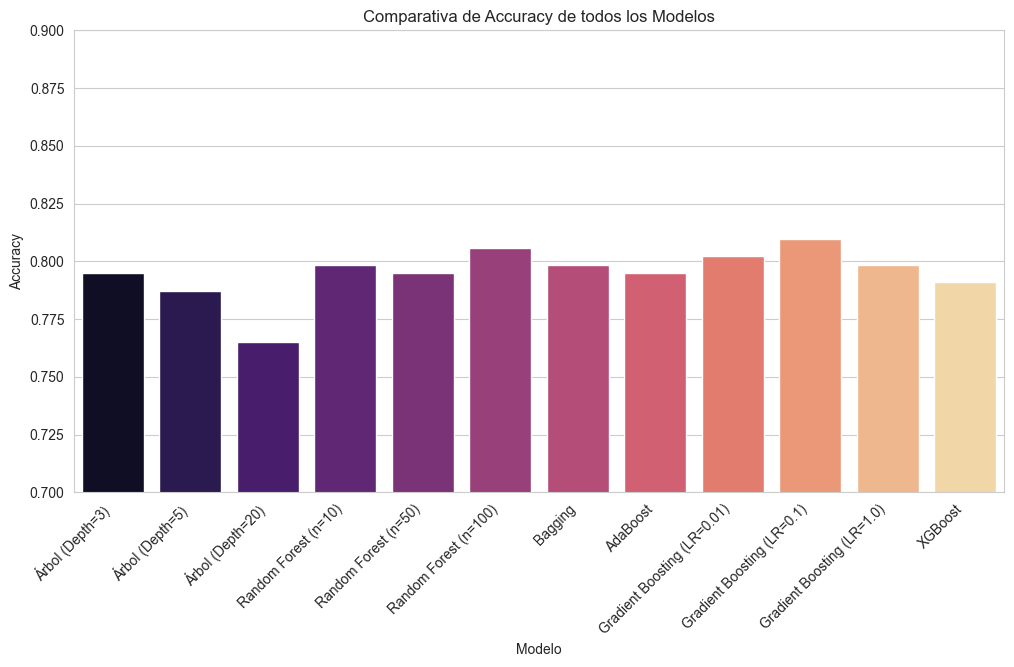

In [25]:
# Convertimos la lista de resultados en un DataFrame
df_res = pd.DataFrame(resultados).set_index('Modelo')

print("=== TABLA RESUMEN FINAL ===")
# Ordenamos por Accuracy de mayor a menor
display(df_res.sort_values(by='Accuracy', ascending=False))

# Gráfica final
plt.figure(figsize=(12, 6))
sns.barplot(x=df_res.index, y=df_res['Accuracy'], palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title("Comparativa de Accuracy de todos los Modelos")
plt.ylim(0.7, 0.9) # Ajustamos eje Y para ver mejor las diferencias
plt.show()